In [ ]:
import marimo as mo

# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.

In [ ]:
import sys
print(sys.executable)

/home/vkut/Documents/uni/tinyml/tinyml-arduino/bin/python3


In [ ]:
from os.path import getsize
from os import makedirs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

import gc
import math

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

tf.keras.backend.clear_session()
gc.collect()

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


In [ ]:
def write_file(path, contents):
    makedirs("./assets/", exist_ok=True)
    with open("./assets/" + path, "wb") as _f:
        _f.write(contents)

def size_kb(path):
    return getsize(f"./assets/{path}") / 1024.0

---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.

In [ ]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)

Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
...                              ...      ...         ...         ...
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                       278.00  1680.00  746.893258  314.907474

[13 rows x 4 columns]

Class distribution:
 Class
0    59
1    71
2    48
Name: count, dtype:

## Problem 1 - Part (a)
### Base Model Training and Evaluation

In [ ]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

X = df.drop(columns=["Class"]).values
y = df["Class"].values

In [ ]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

In [ ]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train_cat,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
13/13 [==============================] - 1s 15ms/step - loss: 1.0042 - accuracy: 0.5455 - val_loss: 0.8110 - val_accuracy: 0.6400
Epoch 2/20
13/13 [==============================] - 0s 6ms/step - loss: 0.7358 - accuracy: 0.8182 - val_loss: 0.5938 - val_accuracy: 0.9200
Epoch 3/20
13/13 [==============================] - 0s 5ms/step - loss: 0.5643 - accuracy: 0.9192 - val_loss: 0.4500 - val_accuracy: 0.9600
Epoch 4/20
13/13 [==============================] - 0s 5ms/step - loss: 0.4266 - accuracy: 0.9596 - val_loss: 0.3342 - val_accuracy: 0.9600
Epoch 5/20
13/13 [==============================] - 0s 6ms/step - loss: 0.3145 - accuracy: 0.9495 - val_loss: 0.2471 - val_accuracy: 1.0000
Epoch 6/20
13/13 [==============================] - 0s 5ms/step - loss: 0.2286 - accuracy: 0.9798 - val_loss: 0.1834 - val_accuracy: 1.0000
Epoch 7/20
13/13 [==============================] - 0s 5ms/step - loss: 0.1716 - accuracy: 0.9899 - val_loss: 0.1408 - val_accuracy: 1.0000
Epoch 8/20
13/13 [=

In [ ]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

_test_loss, _test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Accuracy: {_test_acc:.4f}")
print(f"Test Loss: {_test_loss:.4f}")

_y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
_y_true = np.argmax(y_test_cat, axis=1)

print("\nClassification Report:")
print(classification_report(_y_true, _y_pred, target_names=wine.target_names))

print("Confusion Matrix:")
print(confusion_matrix(_y_true, _y_pred))

Test Accuracy: 0.9815
Test Loss: 0.0518

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.95      0.98        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Confusion Matrix:
[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


In [ ]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model_base = _converter.convert()

write_file("model_base.tflite", tflite_model_base)

print(
    f"Base (float32) TFLite model size: {size_kb('model_base.tflite'):.2f} KB"
)

2026-07-23 23:03:37.517908: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:37.517943: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:37.518155: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmsvy0m4i
2026-07-23 23:03:37.519190: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:37.519210: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmsvy0m4i
2026-07-23 23:03:37.521947: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:37.540568: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpmsvy0m4i
2026-07-23 23:03:37.545722: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 27574 m

Base (float32) TFLite model size: 14.07 KB


## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)

In [ ]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i : i + 1].astype(np.float32)]

def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == "int8":
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: representative_data_gen(
            X_train_scaled
        )
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8
        ]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    elif quant_type == "float16":
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif quant_type == "dynamic":
        # (a) Enable default optimizations.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    else:
        raise ValueError(
            "quant_type must be one of: 'int8', 'float16', or 'dynamic'."
        )

    # Step 2: Convert the model and save it to the provided filename.

    tflite_quantized = converter.convert()

    write_file(filename, tflite_quantized)

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    interpreter = tf.lite.Interpreter(model_path=f"./assets/{filename}")
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # check if input/output are quantized (int8)
    is_input_quantized = input_details[0]["dtype"] == np.int8
    is_output_quantized = output_details[0]["dtype"] == np.int8

    # get quantization parameters for int8 models
    input_scale = input_details[0]["quantization"][0]
    input_zero_point = input_details[0]["quantization"][1]
    output_scale = output_details[0]["quantization"][0]
    output_zero_point = output_details[0]["quantization"][1]

    y_pred = []
    for i in range(len(X_test)):
        sample = X_test[i : i + 1].astype(np.float32)

        # quantize input if needed
        if is_input_quantized:
            sample = np.round(
                sample / input_scale + input_zero_point
            ).astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]["index"])

        # dequantize output if needed
        if is_output_quantized:
            output = (
                output.astype(np.float32) - output_zero_point
            ) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_true = np.argmax(y_test_cat, axis=1)

    # Step 4: Report results.
    print(
        f"\n{quant_type.upper()} TFLite model size: {size_kb(filename):.2f} KB"
    )

    print(f"\nClassification Report ({quant_type}):")
    print(classification_report(y_true, y_pred))

    print(f"\nConfusion Matrix ({quant_type}):")
    print(confusion_matrix(y_true, y_pred))

In [ ]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
# - 'float16' saved as 'model_float16.tflite'
# - 'dynamic' saved as 'model_dynamic.tflite'

quantize_and_evaluate(model, X_test_scaled, y_test_cat, 'int8', "model_int8.tflite")
quantize_and_evaluate(model, X_test_scaled, y_test_cat, 'float16', "model_float16.tflite")
quantize_and_evaluate(model, X_test_scaled, y_test_cat, 'dynamic', "model_dynamic.tflite")

/home/vkut/Documents/uni/tinyml/tinyml-arduino/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-23 23:03:42.219545: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:42.219579: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:42.219716: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmplmj05kqc
2026-07-23 23:03:42.220323: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:42.220333: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmplmj05kqc
2026-07-23 23:03:42.221970: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:42.240488: I tensorflow/cc/saved_mode


INT8 TFLite model size: 5.74 KB

Classification Report (int8):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix (int8):
[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


2026-07-23 23:03:42.874575: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:42.874597: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:42.874715: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkahl1m6r
2026-07-23 23:03:42.875250: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:42.875263: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkahl1m6r
2026-07-23 23:03:42.876827: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:42.895111: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkahl1m6r
2026-07-23 23:03:42.900014: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 25299 m


FLOAT16 TFLite model size: 8.95 KB

Classification Report (float16):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix (float16):
[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


2026-07-23 23:03:43.530769: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:43.530794: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:43.530948: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphhyiv3s8
2026-07-23 23:03:43.531578: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:43.531594: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphhyiv3s8
2026-07-23 23:03:43.533140: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:43.550856: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmphhyiv3s8
2026-07-23 23:03:43.555673: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 24726 m


DYNAMIC TFLite model size: 8.17 KB

Classification Report (dynamic):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.95      0.98        21
           2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix (dynamic):
[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


## Problem 1 - Part (c)

### Pruning

In [ ]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)
epochs_prune = 10
batch_size_prune = 8
# validation_split=0.2 means 80% of train data is used for training
num_train_samples = len(X_train_scaled) * (1 - 0.2)
steps_per_epoch = math.ceil(num_train_samples / batch_size_prune)
total_steps = steps_per_epoch * epochs_prune

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.5,
        final_sparsity=0.7,
        begin_step=0,
        end_step=total_steps,
    )
}

In [ ]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

pruned_model = Sequential(
    [
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(64, activation="relu", input_shape=(num_features,)),
            **pruning_params,
        ),
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(32, activation="relu"), **pruning_params
        ),
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(num_classes, activation="softmax"), **pruning_params
        ),
    ]
)
pruned_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 64)                1730      
 3 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                4130      
 4 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 3)                 197       
 5 (PruneLowMagnitude)                                           
                                                                 
Total params: 6057 (23.67 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 2982 (11.66 KB)
_________________________________________________________________


In [ ]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

pruned_model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

history_pruned = pruned_model.fit(
    X_train_scaled,
    y_train_cat,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
13/13 [==============================] - 1s 17ms/step - loss: 1.1054 - accuracy: 0.3939 - val_loss: 0.9400 - val_accuracy: 0.5600
Epoch 2/10
13/13 [==============================] - 0s 6ms/step - loss: 0.8260 - accuracy: 0.7071 - val_loss: 0.7185 - val_accuracy: 0.7600
Epoch 3/10
13/13 [==============================] - 0s 6ms/step - loss: 0.6256 - accuracy: 0.8990 - val_loss: 0.5266 - val_accuracy: 0.9200
Epoch 4/10
13/13 [==============================] - 0s 6ms/step - loss: 0.4553 - accuracy: 0.9697 - val_loss: 0.3810 - val_accuracy: 0.9600
Epoch 5/10
13/13 [==============================] - 0s 6ms/step - loss: 0.3256 - accuracy: 0.9798 - val_loss: 0.2707 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 6ms/step - loss: 0.2358 - accuracy: 0.9798 - val_loss: 0.1979 - val_accuracy: 1.0000
Epoch 7/10
13/13 [==============================] - 0s 6ms/step - loss: 0.1741 - accuracy: 0.9899 - val_loss: 0.1530 - val_accuracy: 0.9600
Epoch 8/10
13/13 [=

In [ ]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

_converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
_converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_pruned = _converter.convert()

write_file("model_pruned.tflite", tflite_pruned)

print(f"Pruned TFLite model size: {size_kb('model_pruned.tflite'):.2f} KB")

2026-07-23 23:03:37.994513: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:37.994549: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:37.994681: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpr4ovjygi
2026-07-23 23:03:37.995028: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:37.995038: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpr4ovjygi
2026-07-23 23:03:37.995751: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:38.003265: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpr4ovjygi
2026-07-23 23:03:38.006043: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 11364 m

Pruned TFLite model size: 8.24 KB


In [ ]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

_y_pred_pruned = np.argmax(stripped_model.predict(X_test_scaled, verbose=0), axis=1)
_y_true = np.argmax(y_test_cat, axis=1)

print("Classification Report (Pruned):")
print(classification_report(_y_true, _y_pred_pruned))

print("\nConfusion Matrix (Pruned):")
print(confusion_matrix(_y_true, _y_pred_pruned))

Classification Report (Pruned):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix (Pruned):
[[17  1  0]
 [ 0 21  0]
 [ 0  0 15]]


## Problem 1 - Part (d)

### Knowledge Distillation

In [ ]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

student_model = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])
student_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                448       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 3)                 51        
                                                                 
Total params: 1027 (4.01 KB)
Trainable params: 1027 (4.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

teacher_preds_soft = model.predict(X_train_scaled, verbose=0)
print("Teacher predictions shape:", teacher_preds_soft.shape)

Teacher predictions shape: (124, 3)


In [ ]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

# <-- Enter your code here <--#

def distillation_loss(y_true_combined, y_pred):
    """
    Custom loss for knowledge distillation.
    y_true_combined: concatenation of [hard_labels (3 cols), soft_labels (3 cols)]
    y_pred: student model predictions
    """
    y_true_hard = y_true_combined[:, :3]
    y_true_soft = y_true_combined[:, 3:]

    loss_hard = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    loss_soft = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)

    alpha = 0.5
    return alpha * loss_hard + (1.0 - alpha) * loss_soft

In [ ]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

y_train_combined = np.concatenate([y_train_cat, teacher_preds_soft], axis=1)
print("Combined labels shape:", y_train_combined.shape)

student_model.compile(
    optimizer='adam',
    loss=distillation_loss,
    metrics=['accuracy']
)

history_student = student_model.fit(
    X_train_scaled, y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Combined labels shape: (124, 6)
Epoch 1/10
13/13 [==============================] - 1s 16ms/step - loss: 1.0638 - accuracy: 0.4646 - val_loss: 1.0333 - val_accuracy: 0.4800
Epoch 2/10
13/13 [==============================] - 0s 5ms/step - loss: 0.9102 - accuracy: 0.6869 - val_loss: 0.8887 - val_accuracy: 0.7600
Epoch 3/10
13/13 [==============================] - 0s 5ms/step - loss: 0.7826 - accuracy: 0.8283 - val_loss: 0.7671 - val_accuracy: 0.8400
Epoch 4/10
13/13 [==============================] - 0s 6ms/step - loss: 0.6665 - accuracy: 0.9091 - val_loss: 0.6477 - val_accuracy: 0.8800
Epoch 5/10
13/13 [==============================] - 0s 5ms/step - loss: 0.5610 - accuracy: 0.9596 - val_loss: 0.5463 - val_accuracy: 0.9200
Epoch 6/10
13/13 [==============================] - 0s 5ms/step - loss: 0.4650 - accuracy: 0.9697 - val_loss: 0.4611 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 5ms/step - loss: 0.3841 - accuracy: 0.9798 - val_loss: 0.3844 - val_accu

In [ ]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_student = converter.convert()

write_file("model_kd.tflite", tflite_student)

print(f"Student (KD) TFLite model size: {size_kb('model_kd.tflite'):.2f} KB")

2026-07-23 23:03:38.732282: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:38.732308: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:38.732423: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpywsc6gkk
2026-07-23 23:03:38.732964: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:38.732974: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpywsc6gkk
2026-07-23 23:03:38.734396: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:38.752286: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpywsc6gkk
2026-07-23 23:03:38.757175: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 24752 m

Student (KD) TFLite model size: 6.11 KB


In [ ]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

_y_pred_student = np.argmax(student_model.predict(X_test_scaled, verbose=0), axis=1)
_y_true = np.argmax(y_test_cat, axis=1)

print("Classification Report (Student - KD):")
print(classification_report(_y_true, _y_pred_student))

print("\nConfusion Matrix (Student - KD):")
print(confusion_matrix(_y_true, _y_pred_student))

Classification Report (Student - KD):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       1.00      0.81      0.89        21
           2       0.88      1.00      0.94        15

    accuracy                           0.93        54
   macro avg       0.93      0.94      0.93        54
weighted avg       0.93      0.93      0.92        54


Confusion Matrix (Student - KD):
[[18  0  0]
 [ 2 17  2]
 [ 0  0 15]]


## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.

### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.

In [ ]:
# define a new pruning schedule for the student model
epochs_kd_prune = 10
batch_size_kd_prune = 8
num_train_samples_kd = len(X_train_scaled) * (1 - 0.2)
steps_per_epoch_kd = math.ceil(num_train_samples_kd / batch_size_kd_prune)
total_steps_kd = steps_per_epoch_kd * epochs_kd_prune

pruning_params_kd = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.5,
        final_sparsity=0.8,  # Pushing sparsity a bit higher since the model is smaller
        begin_step=0,
        end_step=total_steps_kd,
    )
}

student_pruned = Sequential(
    [
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(32, activation="relu", input_shape=(num_features,)),
            **pruning_params_kd,
        ),
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(16, activation="relu"), **pruning_params_kd
        ),
        tfmot.sparsity.keras.prune_low_magnitude(
            Dense(num_classes, activation="softmax"), **pruning_params_kd
        ),
    ]
)

student_pruned.compile(
    optimizer="adam", loss=distillation_loss, metrics=["accuracy"]
)

student_pruned.fit(
    X_train_scaled,
    y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=1,
)

stripped_student = tfmot.sparsity.keras.strip_pruning(student_pruned)

quantize_and_evaluate(
    stripped_student,
    X_test_scaled,
    y_test_cat,
    "int8",
    "model_kd_prune_int8.tflite",
)

for fname in [
    "model_base.tflite",
    "model_int8.tflite",
    "model_float16.tflite",
    "model_dynamic.tflite",
    "model_pruned.tflite",
    "model_kd.tflite",
    "model_kd_prune_int8.tflite",
]:
    try:
        print(f"  {fname}: {size_kb(fname):.2f} KB")
    except FileNotFoundError:
        print(f"  {fname}: not found")

Epoch 1/10
13/13 [==============================] - 2s 20ms/step - loss: 0.9430 - accuracy: 0.4747 - val_loss: 0.8084 - val_accuracy: 0.7600
Epoch 2/10
13/13 [==============================] - 0s 7ms/step - loss: 0.7949 - accuracy: 0.6263 - val_loss: 0.6777 - val_accuracy: 0.8400
Epoch 3/10
13/13 [==============================] - 0s 7ms/step - loss: 0.6651 - accuracy: 0.7778 - val_loss: 0.5688 - val_accuracy: 0.9600
Epoch 4/10
13/13 [==============================] - 0s 6ms/step - loss: 0.5590 - accuracy: 0.8687 - val_loss: 0.4718 - val_accuracy: 0.9600
Epoch 5/10
13/13 [==============================] - 0s 6ms/step - loss: 0.4621 - accuracy: 0.9192 - val_loss: 0.3914 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 7ms/step - loss: 0.3821 - accuracy: 0.9798 - val_loss: 0.3264 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 6ms/step - loss: 0.3159 - accuracy: 0.9899 - val_loss: 0.2763 - val_accuracy: 0.9600
Epoch 8/10
13/13 [=

/home/vkut/Documents/uni/tinyml/tinyml-arduino/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-23 23:03:41.589945: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-23 23:03:41.589968: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-23 23:03:41.590077: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp536bq12d
2026-07-23 23:03:41.590466: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-23 23:03:41.590476: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp536bq12d
2026-07-23 23:03:41.591208: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-23 23:03:41.599682: I tensorflow/cc/saved_mode


INT8 TFLite model size: 3.64 KB

Classification Report (int8):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       1.00      0.71      0.83        21
           2       0.79      1.00      0.88        15

    accuracy                           0.89        54
   macro avg       0.90      0.90      0.89        54
weighted avg       0.91      0.89      0.88        54


Confusion Matrix (int8):
[[18  0  0]
 [ 2 15  4]
 [ 0  0 15]]
  model_base.tflite: 14.07 KB
  model_int8.tflite: 5.74 KB
  model_float16.tflite: 8.95 KB
  model_dynamic.tflite: 8.17 KB
  model_pruned.tflite: 8.24 KB
  model_kd.tflite: 6.11 KB
  model_kd_prune_int8.tflite: 3.64 KB


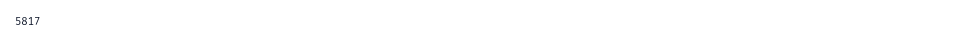

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

# Problem 2: Exploring Edge Impulse (20 points)

### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.